OBJECT DETECION: DAI MODELLI TWO-STAGE ALLA RIVOLUZIONE REAL-TIME

Capacità di una macchina di dire cosa c'è in un'immagine ma anche di localizzale gli oggetti.

Come abbiamo insegnato ai computer a proporre delle zone di interesse?

Evoluzione delle Architetture di Detection
Dalla segmentazione giudata alla regressione end-to-end
I primi approcci efficaci alla object detection si basavano su una pipeline sequenziale. Inizialmente, il sistema individuava regioni potenzialmente interessanti (Region Proposal) e solo successivamente procedeva alla loro classificazione. Questo approccio Two-Stage, pur essendo accurato, risultava estremamente oneroso dal punti di vista computazionale.

Con la maturazione delle disciplina, siamo passati a modelli in grado di trattare la localizzazione e la classificazione come un unico problema di regressione, analizzando l'intera immagine in un singolo passaggio della rete neurale.

Nell'Object Detecion non basta dire cosa c'è nell'immagine, bisogno dire anche dove si trova.
Una CNN di classificazione fa:
Immagine -> CNN -> cane
Un detector fa:
Immagine -> Object Detecotr -> cane 0.96 [x1,y1,x2,y2], persona 0.91 [x1,y1,x2,y2], auto 0.87 [x1,y1,x2,y2]
Quindi l'output contiene almeno:
Classe, confidence, bounding box
La bounding box è il rettangolo dove è contenuto il cane.

Come si trovano i rettangoli velocemente?
Ed è qui che nasce la distinzione fra modelli Two-Stage e One-Stage / Real-Time

*** Modelli Two-Stage ***

Two-Stage significa letteralmente che il problema viene risolto in due fasi
Immagine -> 1) Dove potrebbe esserci oggetti? -> Region Proposal -> 2) Cosa c'è in ciascuna regione? -> Classificazione + Bounding Box
Quindi i modello Two-Stage utilizzano un modulo separato per isalre i candidati prima di passarli al classificatore finale.

* R-CNN
il capostipide moderno
R-CNN significa: Regions with Convolutional Neural Networks
Il principio era:
Immagine -> trova circa 2000 regione candidate -> ritaglia ogni regione -> passa ogni regione nella CNN -> classifica
Prima un algoritmo chiamato Selective Search propone possibile regione:
regione 1, regione 2, regione 3, ..., regione n
Poi ogni regione viene esplorata separatamente dalla CNN
E' intuivivo pa pesantissimo
Essendo la latenza molto elavata, impedisce applcazioni in tempo reale su hardware standard.

Se hai 2.000 regioni esegui 2.000 CNN sulla stessa immagine (regione diversa)

* Fast- R-CNN
Fast R-CNN migliora radicalmente questa parte
Invece di fare:
regione 1 -> CNN   regione 2 -> CNN ... regione 3 -> CNN
fai:
immagine- > CNN una sola volta -> Feature map -> region proposal -> ROI pooling -> classificazione
Quindi la parte costosa della CNN viene eseguita una sola volta
ROI significa: Region Of Interest
La rete prende dalle feature map soltanto la zona relativa alla regione proposta.
Ma rimane un problema: Fast R-CNN utilizza ancora un algoritmo esterno per generare le region proposals.

* Faster R-CNN
Faster R-CNN intorduce una seconda rete neurale
RPN: Region Proposal NetWork
Ora hai due stage neurali
Questo è il classivo Two-Stage Detector
Vantaggio, principalmente è l'accuratezza.
Svantaggio: più elaborazione -> maggiore latenza

* One-Stage Detecion
Perchè prima devo proporre le regioni e poi classificare?
Perchè non posso guardare l'intera immagine una volta sola e produrre direttamente
bounding box + classe + confidence
Da qui: YOLO
Algoritmo  YOLO (You Only Look Once) che predicono simultaneamente classi e coordinate spaziali partendo dai pixel grezzi
YOLO non cerca regioni, con un colpo d'occhio  guarda l'immagine e cerca dove sono gli oggetti e cosa sono.
La rimozione della fase di proposta esplicita, permette ai modelli one-shot di sfruttare meglio le ottimizzazioni delle GPU moderne.
immagine -> una rete -> bounding boxes + classi + confidence

Questo è il passaggio fondamentale verso il Real-Time Object Detection

Ma come si è arrivata a rendere questo processo davvero veloce?

Archiretture SOTA e Confronto
L'approccio R-CNN ha introdotto l'uso della CNN per estrarre feature dalla regioni, ma la letenza era dovuta all'esecuzione della rete per ogni singola proposta. Fast R-CNN ha risolto questo problema estraendo le feature una sola volta per l'intera immagine
Faster R-CNN ha eliminato la dipendenza da algoritmi esterni di ricerca selettiva introducendo la Region Proposal Network (RPN) interna alla rete, rendendo il sistema quasi real-time
Tuttavia YOLO ha cmabiato le regole del gioco dividendo l'immagine in una griglia. Ogni cella è responsabile della predizione di un certo numero di box e della probabilità della classe, eliminando totalmente la necessità di una rete di propsta.


Ma come fa una rete ad imparare a disegnare rettangoli?

Logica della Regressione Spaziale
La funzione di costo multi-task
Nei modelli moderni, la loss function deve gestire contemporaneamente l'errore di classificazione e l'errore di localizzazione delle coordinate. Dobbiamo minimizzare la funzione di costo che punisce sia l'errore di classificazione sia lo spostamente del box rispetto alla realtà.
Questo richiede un bilanciamento accurato per evitare che la rete diventi molto brava a riconoscere l'oggetto ma imprecisa nel tracciarne i confini
Il calcolo della loss include tipicamente il termine per le coordinate del centro, le dimensioni del box e l'errore di confidenza della presenza dell'oggetto. 

Come ne misuramo la qualità?

Geometria e Validazione dei Box
Rappresentazione dei dati e metriche di sovrapposizione
Per addestrare e valutare un modello di object detection, non basta sapere 'cosa' c'è nell'immagine, ma dobbiamo difinire 'dove' si trova con precisione millimetrica.
Questo avviene tramite rettangoli chiamati Bounding Boxes.
Una volta ottenuta una predizione, abbiamo bisogno di un metodo matematico oggettivo per stabili quanto questa sia vicina alla realtà definita dai dati di annotazione (Ground Truth)

Come facciamo a dire se un box è giusto o totalmente sbagliato?
dobbiamo definire un linguaggio comune basato sui pixel, questo linguaggio si base su una struttura semplicissima ma potentissima: la Bounding Box

Anatomia della Bounding Box
Parametrizzazione e confronto spaziale.
La bounding box è il nostro atomo informativo contiene l'essenza spaziale dell'oggetto
- Definizione geometrica: un box è identificato da quattro valori solitamente (x,y,w,h) o (x_min,y_min,x_max,y_max)
- Ground Truth: rappresenta il box ideale disegnato manualmente dall'operatoer umano durante la fase di labbeling del dataset
- Predicted Box: il rettangolo generato dal modello durante l'inferenza, accompagnato da uno score di confidenza
- Intersection over Union (IoU) lametrica standard per misurare la sovrapposizione tra due arre rettangolari.

Il modello (predicte box) cerca di abbraciare la verità (ground Truth) nel modo più preciso possibile.  Per farlo usiamo lo score di confidenza è quanto il modello è sicuro di ciò che ha appena disegnato.
Ma abbraciare non basta, serve anche una misura di sovrapposizione

La metrica sovrano per calcolare la misura di sovrapposizione è IoU
Il Calcolo dell'IoU
l'Area di Intersezione si calcola come la superficie comuna ai due rettangoli. Se non c'è sovrapposizione è zero e la predizione è considerata un fallimento totale.
L'area di Unione rappresenta l'area totalmente coperta da entrambi i box. Serve a penalizzare le predizioni troppo grandi che, pur contenendo l'oggetto risultano imprecise.
Un valore di IoU pari a 1 indica una sovrappposizione perfetta. Solitamente si imposta una soglia (threshold) di 0.5 per considerare una detenzione come corretta (True Positive)

Formalizzazione Matematica
Indice di Jaccard applicato alle immagini
L'IoU è tecnicamente un'applicazione dell'indice di Jaccard per misurare la similarità tra insieme.
Nel nostro caso, gli insiemi sono pixel contenuti all'interno dei confini della Bounding Box
Questa matrice è invariante alla scala, il che significa che funziona bene sia per oggetti molto piccoli che per oggetti molto grandi all'interno del frame.

Quanto è veloce?

Performance: Il Bilancio Critico
Velocità di elaborazione contro precisione del rilevamento
In un contesto industriale o di ricerca, non esiste un modello 'migliore' in assoluto. La scelta dell'algoritmo dipende strettamente dai vincoli hardware e dai requisiti dell'applicazione finale.
Un sistema per la guida autonoma richiede tempi di risposta immediati (alta velocità), mentre un sistema di analisi medica radiografica privilegia la precisione assoluta, anche a costo di attendere diversi secondi per il risultato.

Metriche di Valutazione
Valutare l'efficienza reale del modello
* FPS (Framnes per Second, fotogramma al secondo): misura la velocità di inferenza. Determina se il modello può essere utilizzato in applicazioni video in tempo reale
* Latenza: il tempo necessario per processare una singola immagine, misurato solitamente in millisecondi (ms)
* Precisione e Recall: fondamentali per capire quanti oggetti rilevati sono corretti e quanti oggetti reali sono stati ignorati.
* mAP (mean Average Precion): la metrica riassuntiva che calcola la precizione media su diverse classi e soglie di IoU

Per riunire questi dati in un unico voto finale usiamo mAP

Analisi del mAP
- Average Precisio (AP): si calcola l'area sotto la curva Precisione-Recall per una singola classe. Maggiore è l'area, più il modello è robusto per qualla specifica categoria
E' come se fosse il voto di una singola materia
- Mean AP: è la media aritmetica degli AP calcolati per tutte le classi del dataset (es. le 80clssi di COCO). Fornisce un voto globale alla capacità del modello
E' cone fosse la media di tutti i voti riassunti nella pagella
- Il compromesso mAP@0.5 e mAP@0.5:0.95: spesso il mAP viene calcolato su una media di diverse soglie di IoU per premiare i modello che sono estremamente precisi nel posizionamento dei box.

Frontiera di Pareto di Object Detection
Non puoi avere la massima velocità e la massima precisione contemporanemente
Analisi del trade-off FPS vs Accuracy
Aumentando la risoluzione dell'immagine in input, il mAP solitamente migliora perchè i dettagli sono più visibili, ma gli FPS calano drasticamente a causa dell'aumento delle operazioni di convoluzione
I ricercatori lavorano per spostare la frontiera: ottenere modelli che mantengano un mAP elevato riducendo il numero di parametri (es. versioni 'tiny' o 'nano' di YOLO)


Caricamento del cervello IA (yolo_v8_m_pascalvoc)...
L'IA sta analizzando la foto... attendere...
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Analisi completata! Guarda il file 'risultato_yolo_iou.png'


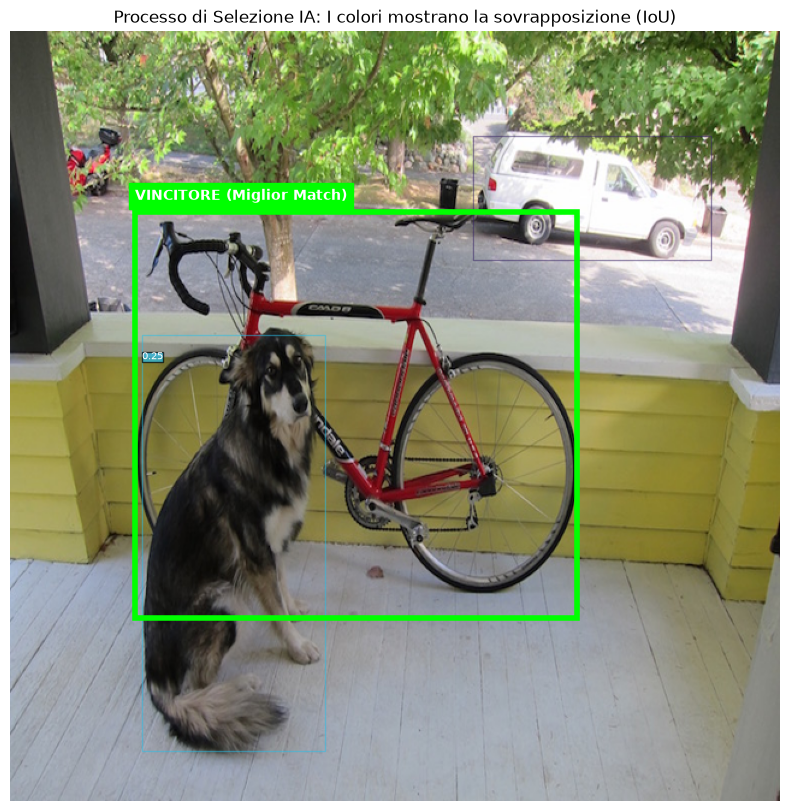

In [3]:
# python -m pip install --upgrade keras-cv
import os

# --- [FASE 1]: CONFIGURAZIONE DEL MOTORE ---
# Spieghiamo al computer quale "motore" usare per far girare l'Intelligenza Artificiale.
# Usiamo TensorFlow perché è molto stabile per caricare modelli già pronti.
os.environ["KERAS_BACKEND"] = "tensorflow" 

import keras
import keras_cv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import requests
from io import BytesIO

class YOLONMSVisualizer:
    """
    Questa classe è come un "laboratorio" che usa YOLOv8 (un'IA molto famosa)
    per trovare oggetti nelle foto e decidere quale sia il riquadro migliore.
    """

    def __init__(self, model_preset="yolo_v8_m_pascalvoc"):
        """
        [PASSO 1.1]: Accendiamo il cervello dell'IA.
        Scarichiamo un modello pre-addestrato che sa già riconoscere oggetti comuni.
        """
        print(f"Caricamento del cervello IA ({model_preset})...")
        self.model = keras_cv.models.YOLOV8Detector.from_preset(
            model_preset,
            bounding_box_format="xyxy", # x_min, y_min, x_max, y_max
        )

    def calculate_iou(self, box1, box2):
        """
        [PASSO 2]: La matematica della "Sovrapposizione" (IoU).
        L'IoU (Intersection over Union) ci dice quanto due rettangoli sono sovrapposti.
        Serve per capire se due riquadri stanno guardando lo stesso identico oggetto.
        """
        # Troviamo i confini della zona dove i due rettangoli si toccano
        x_left = max(box1[0], box2[0])
        y_top = max(box1[1], box2[1])
        x_right = min(box1[2], box2[2])
        y_bottom = min(box1[3], box2[3])

        # Se i rettangoli non si toccano affatto
        if x_right <= x_left or y_bottom <= y_top:
            return 0.0

        # Calcoliamo l'area della zona di scontro (intersezione)
        intersection_area = (x_right - x_left) * (y_bottom - y_top)
        
        # Calcoliamo l'area totale dei due rettangoli
        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
        
        # Formula: Area di scontro diviso Area Totale (meno il doppione)
        union_area = area1 + area2 - intersection_area
        return intersection_area / union_area

    def load_image(self, url):
        """
        [PASSO 3]: Recupero della foto.
        Scarichiamo l'immagine da internet e la adattiamo alla misura 640x640,
        che è quella preferita dall'IA.
        """
        headers = {'User-Agent': 'Mozilla/5.0'}
        res = requests.get(url, headers=headers, timeout=15)
        res.raise_for_status()
        
        img = Image.open(BytesIO(res.content)).convert("RGB")
        return np.array(img.resize((640, 640)))

    def perform_analysis(self, image_url):
        """
        [FASE 2]: L'INFERENZA (L'IA entra in azione).
        Qui diamo la foto all'IA e lei ci restituisce migliaia di ipotesi su dove siano gli oggetti.
        """
        image = self.load_image(image_url)
        
        # Prepariamo la foto per l'IA (aggiungiamo una dimensione "batch")
        input_data = np.expand_dims(image, axis=0)
        
        print("L'IA sta analizzando la foto... attendere...")
        output = self.model.predict(input_data)
        
        # Prendiamo i risultati: riquadri (boxes) e punteggi di sicurezza (confidence)
        boxes = output['boxes'][0]
        confs = output['confidence'][0]
        
        # Filtriamo: teniamo solo i riquadri con almeno il 10% di sicurezza
        # per vedere la "nuvola" di tentativi che l'IA fa prima di decidere.
        mask = confs > 0.1
        candidates = boxes[mask]
        
        if len(boxes) > 0:
            # Il primo riquadro [0] è il "Vincitore" scelto dall'algoritmo NMS
            self.plot_results(image, candidates, boxes[0])
        else:
            print("Nessun oggetto trovato.")

    def plot_results(self, image, candidates, final_box):
        """
        [FASE 3]: VISUALIZZAZIONE GRAFICA.
        Creiamo un disegno che mostra il processo decisionale dell'IA.
        """
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(image)
        
        # Usiamo una scala di colori (da blu a rosso) per l'IoU
        cmap = plt.colormaps.get_cmap('turbo')

        # DISEGNIAMO TUTTI I CANDIDATI (I "perdenti")
        for i, box in enumerate(candidates):
            score = self.calculate_iou(box, final_box)
            
            # Se è quasi identico al vincitore, non lo disegniamo come candidato
            if score > 0.99: continue

            color = cmap(score)
            # Disegniamo rettangoli sottili e trasparenti
            rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                   linewidth=1, edgecolor=color, facecolor='none', alpha=0.5)
            ax.add_patch(rect)
            
            # Mostriamo il punteggio di sovrapposizione vicino al box
            if score > 0.05:
                ax.text(box[0], box[1] + (i % 5) * 10, f"{score:.2f}", color='white',
                        fontsize=7, bbox=dict(facecolor=color, alpha=0.7, pad=0))

        # DISEGNIAMO IL VINCITORE (Il riquadro finale scelto)
        f_rect = patches.Rectangle((final_box[0], final_box[1]), final_box[2]-final_box[0], 
                                 final_box[3]-final_box[1], linewidth=4, 
                                 edgecolor='#00FF00', facecolor='none', zorder=10)
        ax.add_patch(f_rect)
        
        # Mettiamo un'etichetta grande e chiara
        ax.text(final_box[0], final_box[1]-10, "VINCITORE (Miglior Match)", color='white',
                fontsize=10, fontweight='bold', backgroundcolor='#00FF00', zorder=11)

        plt.title("Processo di Selezione IA: I colori mostrano la sovrapposizione (IoU)")
        plt.axis('off')
        
        # Salviamo il risultato finale
        plt.savefig("risultato_yolo_iou.png", bbox_inches='tight')
        print("Analisi completata! Guarda il file 'risultato_yolo_iou.png'")
        plt.show()

# --- [AVVIO DEL PROGRAMMA] ---
if __name__ == "__main__":
    # Usiamo una famosa immagine di test (cane, bicicletta, auto)
    URL_TEST = "https://raw.githubusercontent.com/pjreddie/darknet/master/data/dog.jpg"
    
    # Creiamo l'analizzatore e lanciamo l'IA sulla foto
    analizzatore = YOLONMSVisualizer()
    analizzatore.perform_analysis(URL_TEST)